# All-sky duty cycle

How much of a time window can Pandora observe each patch of sky?  This
notebook sweeps a regular RA/Dec grid over one window and contours the
**duty cycle** — the percentage of the window a target at that coordinate
clears every constraint.

- **Cell 1** — imports.  The helper functions live in `skymap_helpers.py`
  beside this notebook.
- **Cell 2** — everything you edit: the UTC start, the window length in
  days, the time and sky grid resolutions, the TLE, and the `Visibility`
  instance.
- **Cell 3** — the sweep itself, one `get_visibility_best_roll` call per
  grid point.
- **Cell 4** — the duty-cycle contour map, plus the longest continuous
  window at each coordinate.
- **Cell 5** — the mean roll angle the roll search settled on, and how
  much it varies across the window.
- **Cell 6** — area-weighted summary statistics.

The window length is the `duration_days` setting, and every duty cycle
below is a fraction of *that* span, so a one-day run and a two-week run
answer different questions.  Over a single day the Sun keep-out alone
blocks a little over half the sky outright; over a season that blocked
region sweeps round the ecliptic and nothing is permanently lost.

In [1]:
import matplotlib.pyplot as plt
from astropy import units as u

from skymap_helpers import (
    body_radec,
    build_sky_grid,
    build_time_grid,
    duty_cycle_map,
    duty_summary,
    plot_duty_distribution,
    plot_duty_rectangular,
    plot_roll_map,
    resolve_start_time,
    roll_summary,
)
from pandoravisibility import Visibility

## Edit this cell

`start_utc = None` starts the window at 00:00 UTC **today**; put an ISO
timestamp there to pin it, e.g. `"2026-08-10T18:30:00"`.  Everything is
UTC.

`ra_step` / `dec_step` set the cost: the sweep is one visibility solve per
grid point, so halving both steps quadruples the runtime.  Reckon on
roughly 30 ms per grid point for a one-day window — 5° is about 2,700
points and a minute and a half, 1° is about 65,000 points and half an
hour.  Runtime also scales with `duration_days`, since a longer window
holds more orbits to search for a roll angle in: the 27-day window below
costs closer to 0.9 s per grid point, so the 5° grid is about 36 minutes
in one process.

`n_workers` spreads those grid points over worker processes — they are
independent, so this changes nothing but the wall clock.  `None` picks a
count automatically and is what you want for anything past a few hundred
points; `1` keeps everything in this process, which is easier to
interrupt and to read a traceback from.  Expect roughly 4x rather than one
speed-up per core: each solve streams tens of megabytes of orbit samples,
so memory bandwidth saturates long before the cores do, and the 5° grid
lands near 9 minutes instead of 36.

Resolution only changes how finely the maps are drawn, never the numbers:
every grid point is solved independently at its exact coordinate, with no
interpolation between them.

In [17]:
# Time window (UTC)
start_utc = None          # None → today at 00:00 UTC; or "2026-08-10T18:30:00"
duration_days = 30.0       # the "X" every duty cycle below is a fraction of
time_step_minutes = 5.0  # visibility sampling cadence

# Sky grid resolution, in degrees
ra_step = 3.0
dec_step = 3.0

# Spacecraft orbit
# Draft TLE for Pandora — use the most up-to-date one for real work!
line1 = "1 67395U 80229J   26222.21269676  .00000000  00000-0  37770-3 0    04"
line2 = "2 67395  97.8077 220.0392 0004516 329.5253 289.8444 14.88162193    05"

visibility = Visibility(
    line1, line2,
    earthlimb_day_min=44 * u.deg,
    earthlimb_night_min=13 * u.deg,
    sun_min=91 * u.deg,
    moon_min=20 * u.deg,
    st_sun_min=50 * u.deg,
    st_moon_min=20 * u.deg,
    st_earthlimb_min=30 * u.deg,
    st_required=1,
    use_dynamic_earthlimb=False,
    use_dynamic_earthlimb_st=False,
    # Sun/Moon evaluated hourly and interpolated instead of at every
    # timestep.  Their directions stay good to well under 0.01 deg, and
    # long multi-target runs get several times faster.  Drop this line to
    # evaluate the ephemeris exactly.
    ephemeris_step=60 * u.min,
)

# Roll sweep settings, passed straight to get_visibility_best_roll.  A
# coarser roll_step (4 deg) and orbit_time_step (2 min) run about 40%
# faster and move a typical duty cycle by well under a percent.
roll_step = 2 * u.deg
orbit_time_step = 1 * u.min

# Worker processes for the sweep.  None = choose automatically, 1 = solve
# everything in this process.
n_workers = 12

start = resolve_start_time(start_utc)
times = build_time_grid(start, duration_days, time_step_minutes)
ra_vals, dec_vals = build_sky_grid(ra_step, dec_step)

print(visibility)
print(f"Orbital period: {visibility.get_period():.2f}")
print(f"Window: {duration_days:g} d from {start.iso} UTC, "
      f"{len(times)} steps of {time_step_minutes:g} min")
print(f"Sky grid: {len(ra_vals)} RA x {len(dec_vals)} Dec = "
      f"{len(ra_vals) * len(dec_vals)} points")

<Visibility: SAT67395 [moon≥20 deg, sun≥91 deg, limb_day≥44 deg, limb_night≥13 deg, st_sun≥50 deg, st_moon≥20 deg, st_limb≥30 deg, st_req=1]>
Orbital period: 96.76 min
Window: 30 d from 2026-08-11 00:00:00.000 UTC, 8640 steps of 5 min
Sky grid: 120 RA x 61 Dec = 7320 points


## Sweep the sky

Every grid point goes through `get_visibility_best_roll`, which picks one
fixed roll angle per orbit and then tests the star tracker keep-outs at
that roll.  The orbit grouping and the Sun/Moon ephemeris do not depend on
the target, so `Visibility` caches them after the first grid point and the
rest of the sweep reuses them.  With `n_workers` set, that first point is
solved here and the warm caches are handed to each worker, so they start
ready rather than rebuilding the same ephemeris apiece.

Alongside the duty cycle the sweep keeps the boresight-only duty cycle —
Sun, Moon and Earth limb, with no star trackers and no roll search — so
the two can be compared later, and the longest continuous visible window
at each coordinate, which is what caps a single uninterrupted observation.

In [18]:
results = duty_cycle_map(
    visibility, ra_vals, dec_vals, times,
    roll_step=roll_step, orbit_time_step=orbit_time_step,
    n_workers=n_workers,
)

# Where the Sun and the Moon sit in the middle of the window, so the
# keep-out holes in the maps below can be identified at a glance.
mid_time = times[len(times) // 2]
markers = {
    "Sun": body_radec("sun", mid_time),
    "Moon": body_radec("moon", mid_time, visibility),
}
for name, (ra_deg, dec_deg) in markers.items():
    print(f"{name}: RA {ra_deg:7.2f} deg, Dec {dec_deg:+7.2f} deg")

  7320 grid points over 12 worker processes, 96 chunks
     771 / 7320 grid points ( 10.5%) — 1m 41s elapsed, ~14m 20s left
    1541 / 7320 grid points ( 21.1%) — 2m 47s elapsed, ~10m 27s left
    2304 / 7320 grid points ( 31.5%) — 3m 39s elapsed, ~7m 57s left
    3064 / 7320 grid points ( 41.9%) — 4m 22s elapsed, ~6m 05s left
    3824 / 7320 grid points ( 52.2%) — 5m 15s elapsed, ~4m 48s left
    4584 / 7320 grid points ( 62.6%) — 6m 05s elapsed, ~3m 38s left
    5344 / 7320 grid points ( 73.0%) — 6m 48s elapsed, ~2m 31s left
    6104 / 7320 grid points ( 83.4%) — 7m 40s elapsed, ~1m 32s left
    6864 / 7320 grid points ( 93.8%) — 8m 05s elapsed, ~32s left
    7320 / 7320 grid points (100.0%) — 8m 13s elapsed, ~0s left
Sun: RA  154.40 deg, Dec  +10.61 deg
Moon: RA  309.17 deg, Dec  -20.16 deg


## Contour map

Filled contours of the duty cycle on plain RA/Dec axes, with labelled
contour lines for looking a specific coordinate up.  The two axes are
drawn to the same scale, so the Sun's 91° keep-out reads as the circle it
actually is; the price is the usual rectangular one, that the polar caps
look far larger than the sky they cover.  The summary statistics further
down weight by solid angle and are unaffected.

The second panel is the longest continuous visible window: the duty cycle
says how much of the window is usable in total, this says how much of it
arrives in one piece.  In low Earth orbit that is capped by the Earth
occultation, so it rarely exceeds an hour whatever the duty cycle.

The colour scale runs the full 0–100% so that maps of different windows
can be compared directly; in low Earth orbit the Earth occults roughly
half of every orbit, so nothing gets far past 50% and the top half of the
ramp stays empty.  Pass `vmax=60` to spread the colours over the range
the data actually occupies.

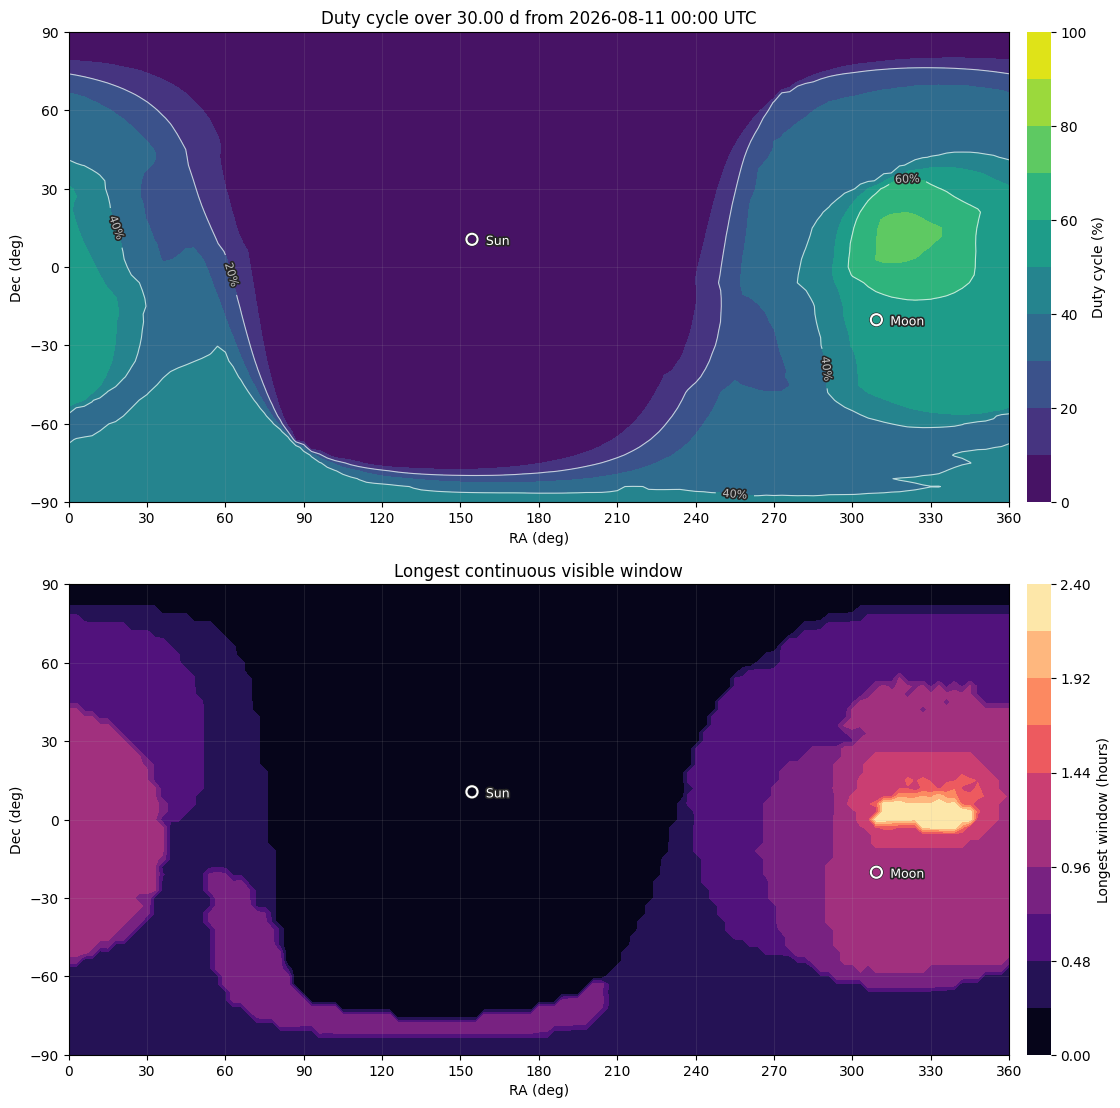

In [19]:
fig = plot_duty_rectangular(results, markers=markers)
plt.show()

## Roll angle

`get_visibility_best_roll` picks one fixed roll for each orbit: the angle
that keeps a star tracker clear of the Sun, Moon and Earth limb over the
most of that orbit's visible time, with solar array power as the
tiebreaker.  The map is the mean of those choices at each coordinate,
each weighted by how long it was actually in use.

Roll is measured from the projection of celestial north onto the plane
perpendicular to the boresight, positive right-handed about the
boresight, on [-180, 180).  Because it wraps, it is averaged as a unit
vector rather than arithmetically — the plain mean of -179° and +179°
would come out as 0°, which is the opposite attitude — and drawn as a
mesh with a cyclic colour map rather than filled contours, which would
interpolate a sweep of false values across the wrap.

The second panel is the circular standard deviation over the window.
Where it is small, one fixed roll would have served the whole window; the
scattered high-spread points are coordinates where the trackers force a
different attitude from one orbit to the next, and there the mean is not
an attitude anyone would fly.  Grey is sky that is never visible.

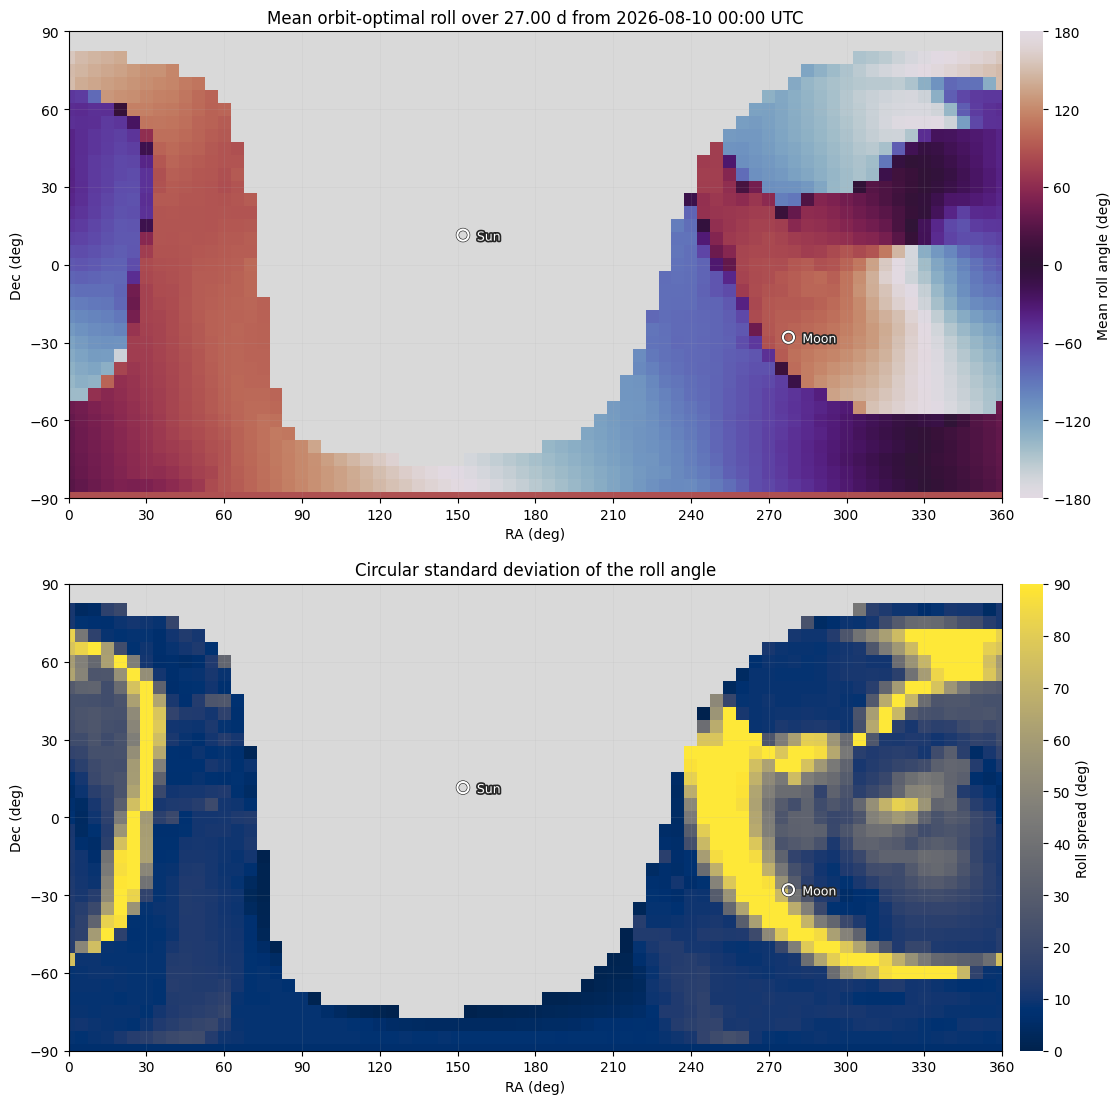

  grid points with a roll   1496 of 2664
  circular mean roll         +93.3 deg
  median roll spread          11.5 deg
  roll steady within 5 deg    5.7% of those points


In [5]:
fig = plot_roll_map(results, markers=markers)
plt.show()

rolls = roll_summary(results)
print(f"  grid points with a roll   {rolls['n_with_roll']} "
      f"of {results['duty'].size}")
print(f"  circular mean roll        {rolls['circular_mean']:+6.1f} deg")
print(f"  median roll spread        {rolls['median_spread']:6.1f} deg")
print(f"  roll steady within 5 deg  "
      f"{100 * rolls['fraction_single_roll']:5.1f}% of those points")

## Summary

Every statistic here is weighted by solid angle, so "half the sky" means
half the sky and not half the grid points — an unweighted mean would
badly over-count the poles, where the RA columns crowd together.

The curve reads as *this fraction of the sky reaches at least this duty
cycle*.  The grey line is the boresight constraints alone, so the gap
between the two is the price of the star tracker keep-outs.

Duty cycle over 27 d from 2026-08-10 00:00 UTC
  area-weighted mean       24.8%   (boresight only: 28.3%)
  median                   17.7%
  10th / 90th percentile    0.0% / 59.4%
  best grid point          81.6%   at RA 320 deg, Dec +20 deg
  never observable         43.6% of the sky
  median longest window      55 min   (over the observable sky)

Sky fraction reaching a given duty cycle
  >=   10%    52.9% of the sky
  >=   25%    47.6% of the sky
  >=   40%    38.1% of the sky
  >=   50%    21.4% of the sky


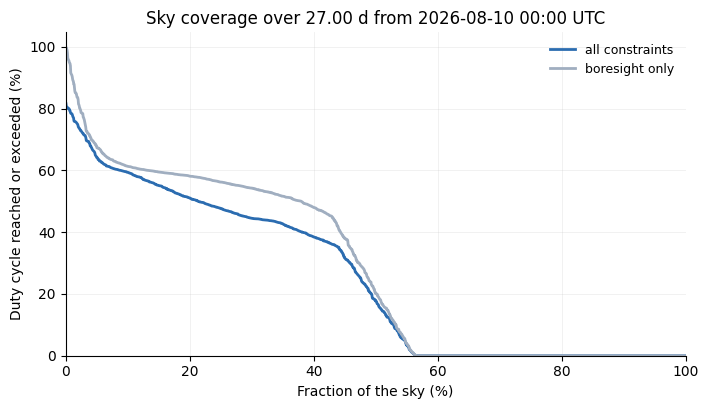

In [6]:
stats = duty_summary(results)

print(f"Duty cycle over {duration_days:g} d from {start.iso[:16]} UTC")
print(f"  area-weighted mean      {stats['mean']:5.1f}%"
      f"   (boresight only: {stats['mean_boresight']:.1f}%)")
print(f"  median                  {stats['median']:5.1f}%")
print(f"  10th / 90th percentile  {stats['p10']:5.1f}% / {stats['p90']:.1f}%")
print(f"  best grid point         {stats['best']:5.1f}%"
      f"   at RA {stats['best_ra']:.0f} deg, Dec {stats['best_dec']:+.0f} deg")
print(f"  never observable        {100 * stats['fraction_never']:5.1f}% of the sky")
print(f"  median longest window   {stats['median_longest_window']:5.0f} min"
      f"   (over the observable sky)")
print("\nSky fraction reaching a given duty cycle")
for level, fraction in stats["fraction_above"].items():
    print(f"  >= {level:4.0f}%   {100 * fraction:5.1f}% of the sky")

ax = plot_duty_distribution(results)
plt.show()